<a href="https://colab.research.google.com/github/hannah-u-dennis/EBUS-Climatechange-upwelling-primaryproductivity/blob/main/tutorials/W1D4_Paleoclimate/student/W1D4_Tutorial3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/neuromatch/climate-course-content/blob/main/tutorials/W1D4_Paleoclimate/student/W1D4_Tutorial3.ipynb) &nbsp; <a href="https://kaggle.com/kernels/welcome?src=https://raw.githubusercontent.com/neuromatch/climate-course-content/main/tutorials/W1D4_Paleoclimate/student/W1D4_Tutorial3.ipynb" target="_parent"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open in Kaggle"/></a>


# Tutorial 3: Reconstructing Past Changes in Terrestrial Climate

**Week 1, Day 4, Paleoclimate**

**Content creators:** Sloane Garelick

**Content reviewers:** Yosmely Bermúdez, Dionessa Biton, Katrina Dobson, Maria Gonzalez, Will Gregory, Nahid Hasan, Paul Heubel, Sherry Mi, Beatriz Cosenza Muralles, Brodie Pearson, Jenna Pearson, Chi Zhang, Ohad Zivan

**Content editors:** Yosmely Bermúdez, Paul Heubel, Zahra Khodakaramimaghsoud, Jenna Pearson, Agustina Pesce, Chi Zhang, Ohad Zivan

**Production editors:** Wesley Banfield, Paul Heubel, Jenna Pearson, Konstantine Tsafatinos, Chi Zhang, Ohad Zivan

**Our 2024 Sponsors:** CMIP, NFDI4Earth

# Tutorial Objectives

*Estimated timing of tutorial:* 20 minutes

In this tutorial, we’ll explore the Euro2K proxy network, which is a subset of PAGES2K, the database we explored in the first tutorial. We will specifically focus on interpreting temperature change over the past 2,000 years as recorded by proxy records from tree rings, speleothems, and lake sediments. To analyze these datasets, we will group them by archive and create time series plots to assess temperature variations.

During this tutorial, you will:

- Plot temperature records based on three different terrestrial proxies
- Assess similarities and differences between the temperature records


# Setup


In [2]:
# installations ( uncomment and run this cell ONLY when using google colab or kaggle )

!pip install LiPD
!pip install cartopy
!pip install pyleoclim==0.14.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 996.4/996.4 kB 15.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 605.7/605.7 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
# imports

# for Google Colab users: you might get a numpy.dtype error here, restart your session and rerun the code and it should solve it.
import pyleoclim as pyleo
import pandas as pd
import numpy as np
import os
import pooch
import tempfile
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from io import StringIO
import sys

In [2]:
# @title Install and import feedback gadget

!pip3 install vibecheck datatops --quiet

from vibecheck import DatatopsContentReviewContainer
def content_review(notebook_section: str):
    return DatatopsContentReviewContainer(
        "",  # No text prompt
        notebook_section,
        {
            "url": "https://pmyvdlilci.execute-api.us-east-1.amazonaws.com/klab",
            "name": "comptools_4clim",
            "user_key": "l5jpxuee",
        },
    ).render()


feedback_prefix = "W1D4_T3"

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.6 MB/s eta 0:00:00


In [3]:
# @title Figure Settings
import ipywidgets as widgets  # interactive display

%config InlineBackend.figure_format = 'retina'
plt.style.use(
    "https://raw.githubusercontent.com/neuromatch/climate-course-content/main/cma.mplstyle"
)

In [4]:
# @title Helper functions


def pooch_load(filelocation=None, filename=None, processor=None):
    # this is different for each day
    shared_location = "/home/jovyan/shared/Data/tutorials/W1D4_Paleoclimate"
    user_temp_cache = tempfile.gettempdir()

    if os.path.exists(os.path.join(shared_location, filename)):
        file = os.path.join(shared_location, filename)
    else:
        file = pooch.retrieve(
            filelocation,
            known_hash=None,
            fname=os.path.join(user_temp_cache, filename),
            processor=processor,
        )

    return file


class SupressOutputs(list):
    def __enter__(self):
        self._stdout = sys.stdout
        sys.stdout = self._stringio = StringIO()
        return self

    def __exit__(self, *args):
        self.extend(self._stringio.getvalue().splitlines())
        del self._stringio  # free up some memory
        sys.stdout = self._stdout

In [5]:
# @title Video 1: Terrestrial Climate Proxies

from ipywidgets import widgets
from IPython.display import YouTubeVideo
from IPython.display import IFrame
from IPython.display import display


class PlayVideo(IFrame):
    def __init__(self, id, source, page=1, width=400, height=300, **kwargs):
        self.id = id
        if source == "Bilibili":
            src = f"https://player.bilibili.com/player.html?bvid={id}&page={page}"
        elif source == "Osf":
            src = f"https://mfr.ca-1.osf.io/render?url=https://osf.io/download/{id}/?direct%26mode=render"
        super(PlayVideo, self).__init__(src, width, height, **kwargs)


def display_videos(video_ids, W=400, H=300, fs=1):
    tab_contents = []
    for i, video_id in enumerate(video_ids):
        out = widgets.Output()
        with out:
            if video_ids[i][0] == "Youtube":
                video = YouTubeVideo(
                    id=video_ids[i][1], width=W, height=H, fs=fs, rel=0
                )
                print(f"Video available at https://youtube.com/watch?v={video.id}")
            else:
                video = PlayVideo(
                    id=video_ids[i][1],
                    source=video_ids[i][0],
                    width=W,
                    height=H,
                    fs=fs,
                    autoplay=False,
                )
                if video_ids[i][0] == "Bilibili":
                    print(
                        f"Video available at https://www.bilibili.com/video/{video.id}"
                    )
                elif video_ids[i][0] == "Osf":
                    print(f"Video available at https://osf.io/{video.id}")
            display(video)
        tab_contents.append(out)
    return tab_contents


video_ids = [("Youtube", "wU2gNOYOXrQ"), ("Bilibili", "BV1s94y1B7Yx")]
tab_contents = display_videos(video_ids, W=730, H=410)
tabs = widgets.Tab()
tabs.children = tab_contents
for i in range(len(tab_contents)):
    tabs.set_title(i, video_ids[i][0])
display(tabs)

In [6]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Terrestrial_Climate_Proxies_Video")

In [7]:
# @markdown
from ipywidgets import widgets
from IPython.display import IFrame

link_id = "6gcsh"

print(f"If you want to download the slides: https://osf.io/download/{link_id}/")
IFrame(src=f"https://mfr.ca-1.osf.io/render?url=https://osf.io/{link_id}/?direct%26mode=render%26action=download%26mode=render", width=854, height=480)

If you want to download the slides: https://osf.io/download/6gcsh/


In [8]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Terrestrial_Climate_Proxies_Slides")

# Section 1: Loading Terrestrial Paleoclimate Records

First, we need to download the data. Similar to Tutorial 1, the data is stored as a LiPD file, and we will be using Pyleoclim to format and interpret the data.


In [9]:
# set the name to save the Euro2k data
fname = "euro2k_data"

# download the data
lipd_file_path = pooch.retrieve(
    url="https://osf.io/7ezp3/download/",
    known_hash=None,
    path="./",
    fname=fname,
    processor=pooch.Unzip(),
)

In [10]:
# the LiPD object can be used to load datasets stored in the LiPD format.
# in this first case study, we will load an entire library of LiPD files:
with SupressOutputs():
    d_euro = pyleo.Lipd(os.path.join(".", f"{fname}.unzip", "Euro2k"))

/tmp/ipykernel_2172/2313300970.py:4: DeprecationWarning: The Lipd class is being deprecated and will be removed in Pyleoclim v1.0.0. Functionalities will instead be handled by the pyLipd package.
  d_euro = pyleo.Lipd(os.path.join(".", f"{fname}.unzip", "Euro2k"))


# Section 2: Temperature Reconstructions


Before plotting, let's narrow the data down a bit. We can filter all of the data so that we only keep reconstructions of temperature from terrestrial archives (e.g. tree rings, speleothems and lake sediments). This is accomplished with the function below.


In [11]:
def filter_data(dataset, archive_type, variable_name):
    """
    Return a MultipleSeries object with the variable record (variable_name) for a given archive_type and coordinates.
    """
    # Create a list of dictionary that can be iterated upon using Lipd.to_tso method
    ts_list = dataset.to_tso()
    # Append the correct indices for a given value of archive_type and variable_name
    indices = []
    lat = []
    lon = []
    for idx, item in enumerate(ts_list):
        # Check that it is available to avoid errors on the loop
        if "archiveType" in item.keys():
            # If it's a archive_type, then proceed to the next step
            if item["archiveType"] == archive_type:
                if item["paleoData_variableName"] == variable_name:
                    indices.append(idx)
    print(indices)
    # Create a list of LipdSeries for the given indices
    ts_list_archive_type = []
    for indice in indices:
        ts_list_archive_type.append(pyleo.LipdSeries(ts_list[indice]))

        # save lat and lons of proxies
        lat.append(ts_list[indice]["geo_meanLat"])
        lon.append(ts_list[indice]["geo_meanLon"])

    return pyleo.MultipleSeries(ts_list_archive_type), lat, lon

In the function above, the [`Lipd.to_tso()`](https://pyleoclim-util.readthedocs.io/en/latest/core/api.html#pyleoclim.core.lipd.Lipd.to_tso) method is used to obtain a list of dictionaries that can be iterated upon.


In [12]:
ts_list = d_euro.to_tso()

extracting paleoData...
extracting: Eur-CoastofPortugal.Abrantes.2011
extracting: Eur-NorthernSpain.Martín-Chivelet.2011
extracting: Eur-MaritimeFrenchAlps.Büntgen.2012
extracting: Arc-Tjeggelvas.Bjorklund.2012
extracting: Arc-Tornetrask.Melvin.2012
extracting: Eur-LakeSilvaplana.Trachsel.2010
extracting: Eur-RAPiD-17-5P.Moffa-Sanchez.2014
extracting: Eur-FinnishLakelands.Helama.2014
extracting: Arc-AkademiiNaukIceCap.Opel.2013
extracting: Eur-LakeSilvaplana.Larocque-Tobler.2010
extracting: Eur-SpanishPyrenees.Dorado-Linan.2012
extracting: Eur-EasternCarpathianMountains.Popa.2008
extracting: Eur-Tallinn.Tarand.2001
extracting: Eur-Stockholm.Leijonhufvud.2009
extracting: Arc-Indigirka.Hughes.1999
extracting: Eur-NorthernScandinavia.Esper.2012
extracting: Eur-Seebergsee.Larocque-Tobler.2012
extracting: Ocn-AqabaJordanAQ19.Heiss.1999
extracting: Arc-Forfjorddalen.McCarroll.2013
extracting: Eur-CentralandEasternPyrenees.Pla.2004
extracting: Eur-Lötschental.Büntgen.2006
extracting: Arc-Kitt

Dictionaries are native to Python and can be explored as shown below.


In [13]:
# look at available entries for just one time-series
ts_list[0].keys()

dict_keys(['mode', 'time_id', '@context', 'archiveType', 'createdBy', 'dataSetName', 'googleDataURL', 'googleMetadataWorksheet', 'googleSpreadSheetKey', 'originalDataURL', 'tagMD5', 'pub1_author', 'pub1_citeKey', 'pub1_dataUrl', 'pub1_issue', 'pub1_journal', 'pub1_pages', 'pub1_publisher', 'pub1_title', 'pub1_type', 'pub1_volume', 'pub1_year', 'pub1_doi', 'pub2_author', 'pub2_Urldate', 'pub2_citeKey', 'pub2_institution', 'pub2_title', 'pub2_type', 'pub2_url', 'geo_type', 'geo_meanLon', 'geo_meanLat', 'geo_meanElev', 'geo_pages2kRegion', 'geo_region', 'geo_siteName', 'lipdVersion', 'tableType', 'paleoData_paleoDataTableName', 'paleoData_paleoDataMD5', 'paleoData_googleWorkSheetKey', 'paleoData_measurementTableName', 'paleoData_measurementTableMD5', 'paleoData_filename', 'paleoData_tableName', 'paleoData_missingValue', 'year', 'yearUnits', 'paleoData_QCCertification', 'paleoData_QCnotes', 'paleoData_TSid', 'paleoData_WDSPaleoUrl', 'paleoData_archiveType', 'paleoData_description', 'paleoD

In [14]:
# print relevant information for all entries
for idx, item in enumerate(ts_list):
    print(str(idx) + ": " + item["dataSetName"] +
          ": " + item["paleoData_variableName"])

0: Eur-CoastofPortugal.Abrantes.2011: temperature
1: Eur-CoastofPortugal.Abrantes.2011: year
2: Eur-NorthernSpain.Martín-Chivelet.2011: d18O
3: Eur-NorthernSpain.Martín-Chivelet.2011: year
4: Eur-MaritimeFrenchAlps.Büntgen.2012: trsgi
5: Eur-MaritimeFrenchAlps.Büntgen.2012: year
6: Arc-Tjeggelvas.Bjorklund.2012: density
7: Arc-Tjeggelvas.Bjorklund.2012: year
8: Arc-Tornetrask.Melvin.2012: temperature
9: Arc-Tornetrask.Melvin.2012: year
10: Arc-Tornetrask.Melvin.2012: temperature
11: Arc-Tornetrask.Melvin.2012: sampleDensity
12: Eur-LakeSilvaplana.Trachsel.2010: temperature
13: Eur-LakeSilvaplana.Trachsel.2010: year
14: Eur-RAPiD-17-5P.Moffa-Sanchez.2014: d18O
15: Eur-RAPiD-17-5P.Moffa-Sanchez.2014: year
16: Eur-FinnishLakelands.Helama.2014: temperature
17: Eur-FinnishLakelands.Helama.2014: year
18: Arc-AkademiiNaukIceCap.Opel.2013: thickness
19: Arc-AkademiiNaukIceCap.Opel.2013: year
20: Arc-AkademiiNaukIceCap.Opel.2013: age
21: Arc-AkademiiNaukIceCap.Opel.2013: d18O
22: Arc-AkademiiNa

Now let's use our pre-defined function to create a new list that only has temperature reconstructions based on proxies from **lake sediments**:


In [15]:
ms_euro_lake, euro_lake_lat, euro_lake_lon = filter_data(
    d_euro, "lake sediment", "temperature"
)

extracting paleoData...
extracting: Eur-CoastofPortugal.Abrantes.2011
extracting: Eur-NorthernSpain.Martín-Chivelet.2011
extracting: Eur-MaritimeFrenchAlps.Büntgen.2012
extracting: Arc-Tjeggelvas.Bjorklund.2012
extracting: Arc-Tornetrask.Melvin.2012
extracting: Eur-LakeSilvaplana.Trachsel.2010
extracting: Eur-RAPiD-17-5P.Moffa-Sanchez.2014
extracting: Eur-FinnishLakelands.Helama.2014
extracting: Arc-AkademiiNaukIceCap.Opel.2013
extracting: Eur-LakeSilvaplana.Larocque-Tobler.2010
extracting: Eur-SpanishPyrenees.Dorado-Linan.2012
extracting: Eur-EasternCarpathianMountains.Popa.2008
extracting: Eur-Tallinn.Tarand.2001
extracting: Eur-Stockholm.Leijonhufvud.2009
extracting: Arc-Indigirka.Hughes.1999
extracting: Eur-NorthernScandinavia.Esper.2012
extracting: Eur-Seebergsee.Larocque-Tobler.2012
extracting: Ocn-AqabaJordanAQ19.Heiss.1999
extracting: Arc-Forfjorddalen.McCarroll.2013
extracting: Eur-CentralandEasternPyrenees.Pla.2004
extracting: Eur-Lötschental.Büntgen.2006
extracting: Arc-Kitt

/tmp/ipykernel_2172/2522667653.py:22: DeprecationWarning: The LipdSeries class is being deprecated and will be removed in Pyleoclim v1.0.0. It will be replaced by the geoSeries class (currently in development).
  ts_list_archive_type.append(pyleo.LipdSeries(ts_list[indice]))


And a new list that only has temperature reconstructions based on proxies from **tree rings**:


In [16]:
ms_euro_tree, euro_tree_lat, euro_tree_lon = filter_data(
    d_euro, "tree", "temperature")

extracting paleoData...
extracting: Eur-CoastofPortugal.Abrantes.2011
extracting: Eur-NorthernSpain.Martín-Chivelet.2011
extracting: Eur-MaritimeFrenchAlps.Büntgen.2012
extracting: Arc-Tjeggelvas.Bjorklund.2012
extracting: Arc-Tornetrask.Melvin.2012
extracting: Eur-LakeSilvaplana.Trachsel.2010
extracting: Eur-RAPiD-17-5P.Moffa-Sanchez.2014
extracting: Eur-FinnishLakelands.Helama.2014
extracting: Arc-AkademiiNaukIceCap.Opel.2013
extracting: Eur-LakeSilvaplana.Larocque-Tobler.2010
extracting: Eur-SpanishPyrenees.Dorado-Linan.2012
extracting: Eur-EasternCarpathianMountains.Popa.2008
extracting: Eur-Tallinn.Tarand.2001
extracting: Eur-Stockholm.Leijonhufvud.2009
extracting: Arc-Indigirka.Hughes.1999
extracting: Eur-NorthernScandinavia.Esper.2012
extracting: Eur-Seebergsee.Larocque-Tobler.2012
extracting: Ocn-AqabaJordanAQ19.Heiss.1999
extracting: Arc-Forfjorddalen.McCarroll.2013
extracting: Eur-CentralandEasternPyrenees.Pla.2004
extracting: Eur-Lötschental.Büntgen.2006
extracting: Arc-Kitt

/tmp/ipykernel_2172/2522667653.py:22: DeprecationWarning: The LipdSeries class is being deprecated and will be removed in Pyleoclim v1.0.0. It will be replaced by the geoSeries class (currently in development).
  ts_list_archive_type.append(pyleo.LipdSeries(ts_list[indice]))


And finally, a new list that only has temperature information based on proxies from **speleothems**:


In [17]:
ms_euro_spel, euro_spel_lat, euro_spel_lon = filter_data(
    d_euro, "speleothem", "d18O")

extracting paleoData...
extracting: Eur-CoastofPortugal.Abrantes.2011
extracting: Eur-NorthernSpain.Martín-Chivelet.2011
extracting: Eur-MaritimeFrenchAlps.Büntgen.2012
extracting: Arc-Tjeggelvas.Bjorklund.2012
extracting: Arc-Tornetrask.Melvin.2012
extracting: Eur-LakeSilvaplana.Trachsel.2010
extracting: Eur-RAPiD-17-5P.Moffa-Sanchez.2014
extracting: Eur-FinnishLakelands.Helama.2014
extracting: Arc-AkademiiNaukIceCap.Opel.2013
extracting: Eur-LakeSilvaplana.Larocque-Tobler.2010
extracting: Eur-SpanishPyrenees.Dorado-Linan.2012
extracting: Eur-EasternCarpathianMountains.Popa.2008
extracting: Eur-Tallinn.Tarand.2001
extracting: Eur-Stockholm.Leijonhufvud.2009
extracting: Arc-Indigirka.Hughes.1999
extracting: Eur-NorthernScandinavia.Esper.2012
extracting: Eur-Seebergsee.Larocque-Tobler.2012
extracting: Ocn-AqabaJordanAQ19.Heiss.1999
extracting: Arc-Forfjorddalen.McCarroll.2013
extracting: Eur-CentralandEasternPyrenees.Pla.2004
extracting: Eur-Lötschental.Büntgen.2006
extracting: Arc-Kitt

/tmp/ipykernel_2172/2522667653.py:22: DeprecationWarning: The LipdSeries class is being deprecated and will be removed in Pyleoclim v1.0.0. It will be replaced by the geoSeries class (currently in development).
  ts_list_archive_type.append(pyleo.LipdSeries(ts_list[indice]))


## Coding Exercises 2

Using the coordinate information output from the `filter_data()` function, make a plot of the locations of the proxies using the markers and colors from Tutorial 1. Note that data close together may not be very visible.


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


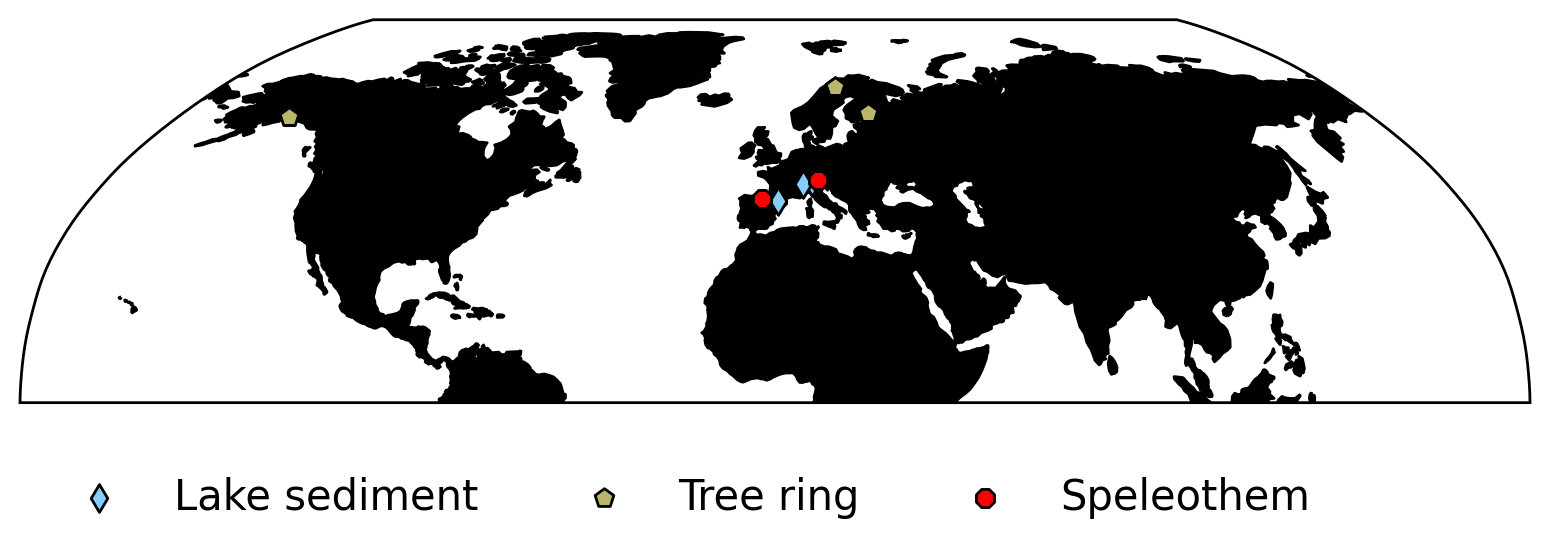

In [18]:

# initiate plot
fig = plt.figure()

# set base map projection
ax = plt.axes(projection=ccrs.Robinson())

ax.set_global()

# add land fratures using gray color
ax.add_feature(cfeature.LAND, facecolor="k")

# add coastlines
ax.add_feature(cfeature.COASTLINE)

# add the proxy locations
_ = ax.scatter(
    euro_lake_lon,
    euro_lake_lat,
    transform=ccrs.Geodetic(),
    label="Lake sediment",
    s=50,
    marker="d",
    color=[0.52734375, 0.8046875, 0.97916667],
    edgecolor="k",
    zorder=2,
)
_ = ax.scatter(
    euro_tree_lon,
    euro_tree_lat,
    transform=ccrs.Geodetic(),
    label="Tree ring",
    s=50,
    marker="p",
    color=[0.73828125, 0.71484375, 0.41796875],
    edgecolor="k",
    zorder=2,
)
_ = ax.scatter(
    euro_spel_lon,
    euro_spel_lat,
    transform=ccrs.Geodetic(),
    label="Speleothem",
    s=50,
    marker="8",
    color=[1, 0, 0],
    edgecolor="k",
    zorder=2,
)

# change the map view to zoom in on central Pacific
ax.set_extent((0, 360, 0, 90), crs=ccrs.PlateCarree())

ax.legend(
    scatterpoints=1,
    bbox_to_anchor=(0, -0.4),
    loc="lower left",
    ncol=3,
    fontsize=15,
)

[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D4_Paleoclimate/solutions/W1D4_Tutorial3_Solution_ead41c6f.py)

*Example output:*

<img alt='Solution hint' align='left' width=775.0 height=277.0 src=https://raw.githubusercontent.com/neuromatch/climate-course-content/main/tutorials/W1D4_Paleoclimate/static/W1D4_Tutorial3_Solution_ead41c6f_1.png>



In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Coding_Exercises_2")

Since we are going to compare temperature datasets based on different terrestrial climate archives (lake sediments, tree rings and speleothems), the quantitative values of the measurements in each record will differ (i.e., the lake sediment and tree ring data are temperature in degrees C, but the speleothem data is oxygen isotopes in per mille). Therefore, to more easily and accurately compare temperature between the records, it's helpful to standardize the data as we did in Tutorial 2. The [`.standardize()`](https://pyleoclim-util.readthedocs.io/en/v0.7.4/core/ui.html#pyleoclim.core.ui.Series.standardize) function removes the estimated mean of the time series and divides by its estimated standard deviation.


In [19]:
# standardize the data
spel_stnd = ms_euro_spel.standardize()
lake_stnd = ms_euro_lake.standardize()
tree_stnd = ms_euro_tree.standardize()

Now we can use Pyleoclim functions to create three stacked plots of this data with lake sediment records on top, tree ring reconstructions in the middle and speleothem records on the bottom.

Note that the colors used for the time series in each plot are the default colors generated by the function, so the corresponding colors in each of the three plots are not relevant.


Text(0.5, 1.2, 'Speleothems')

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


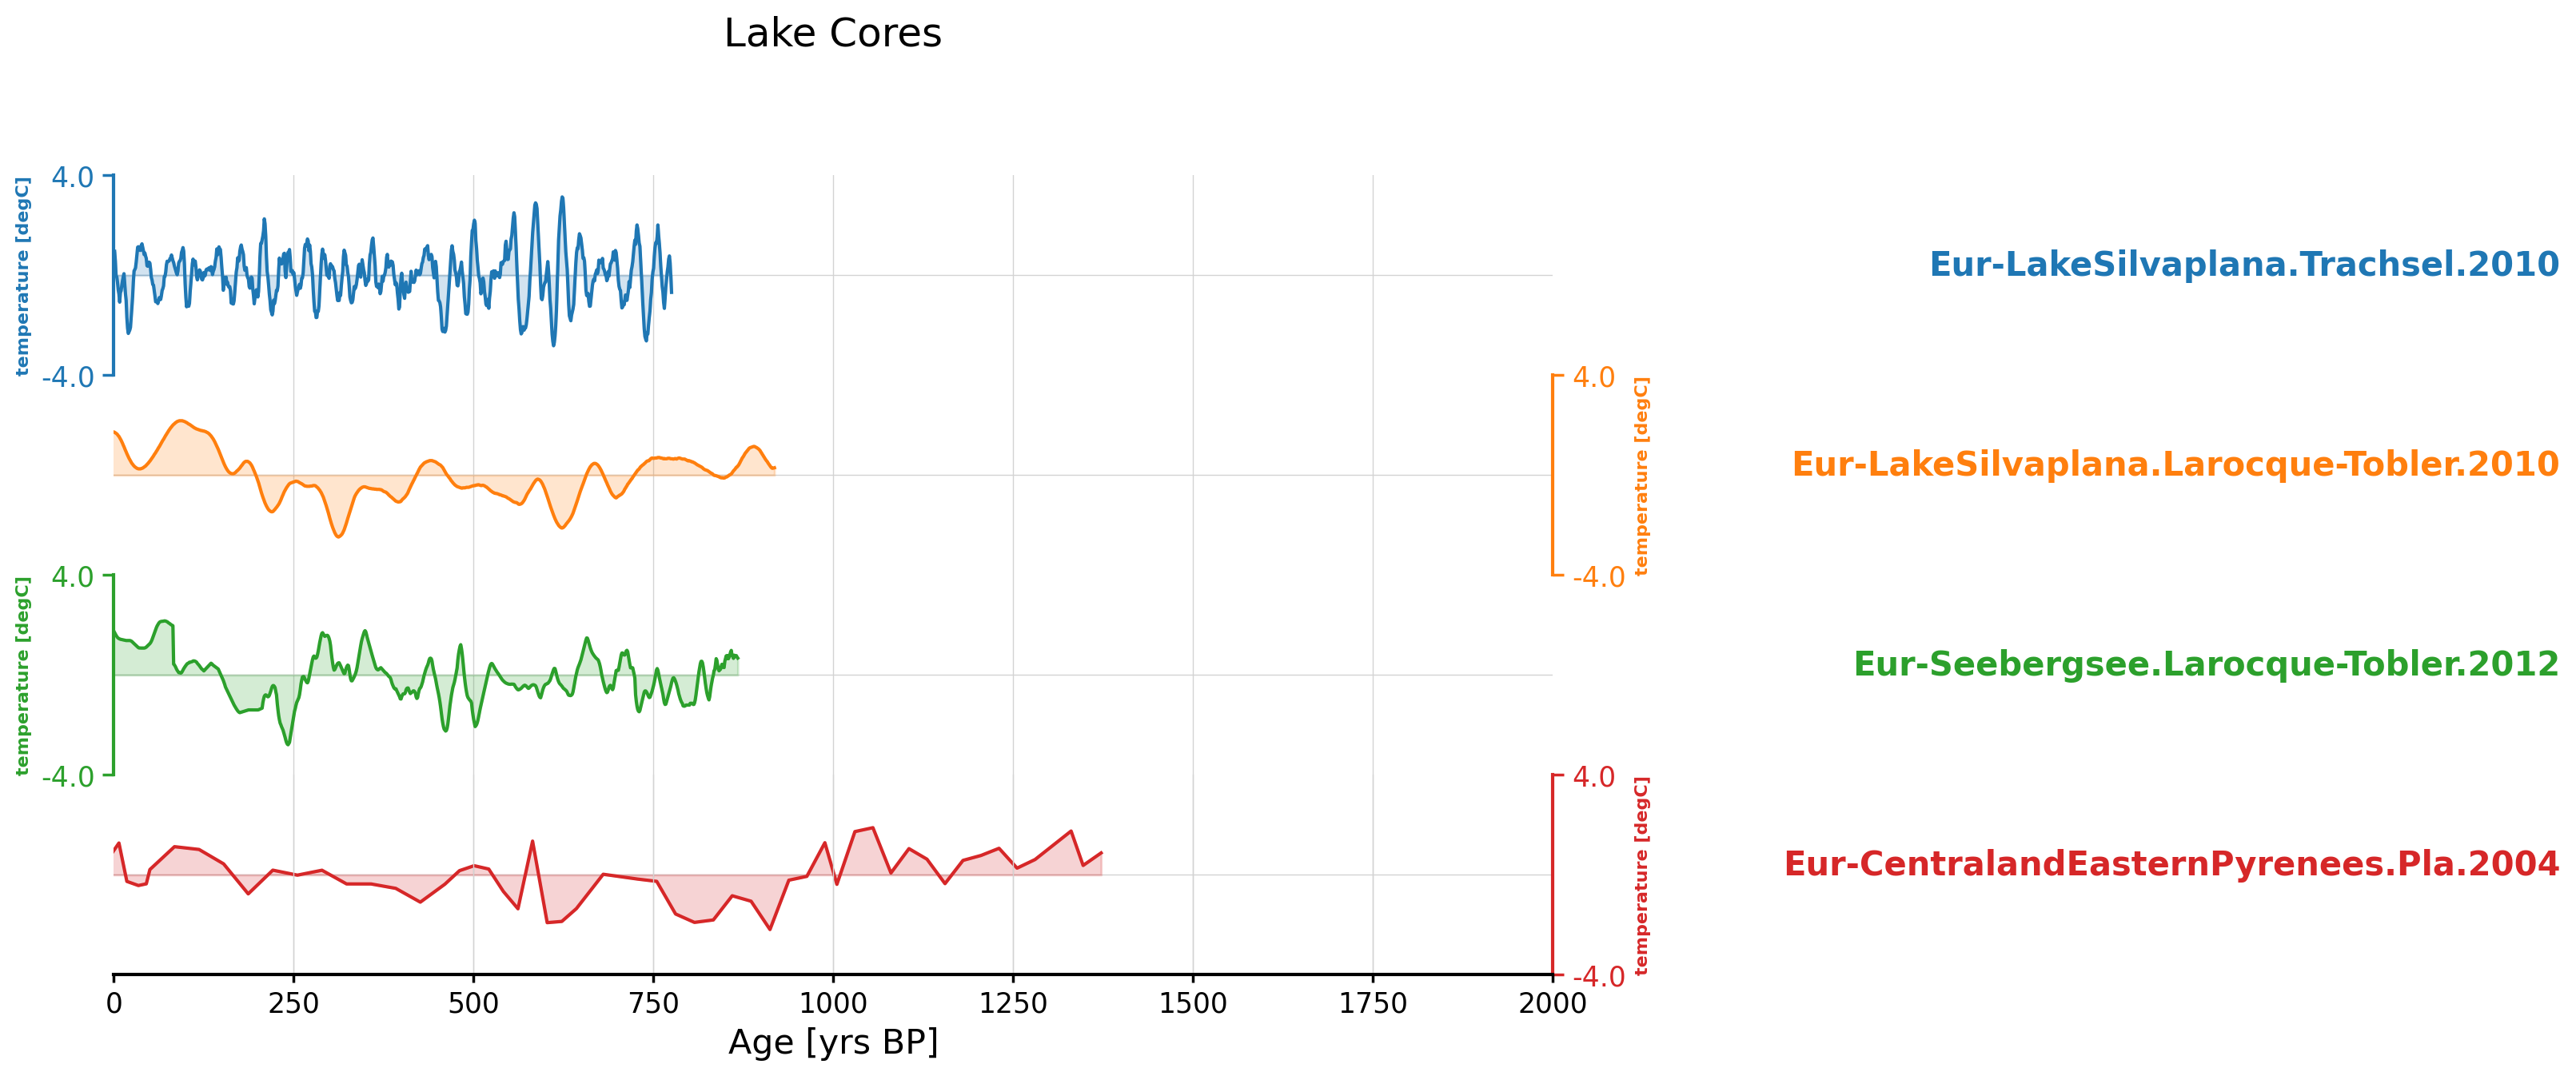

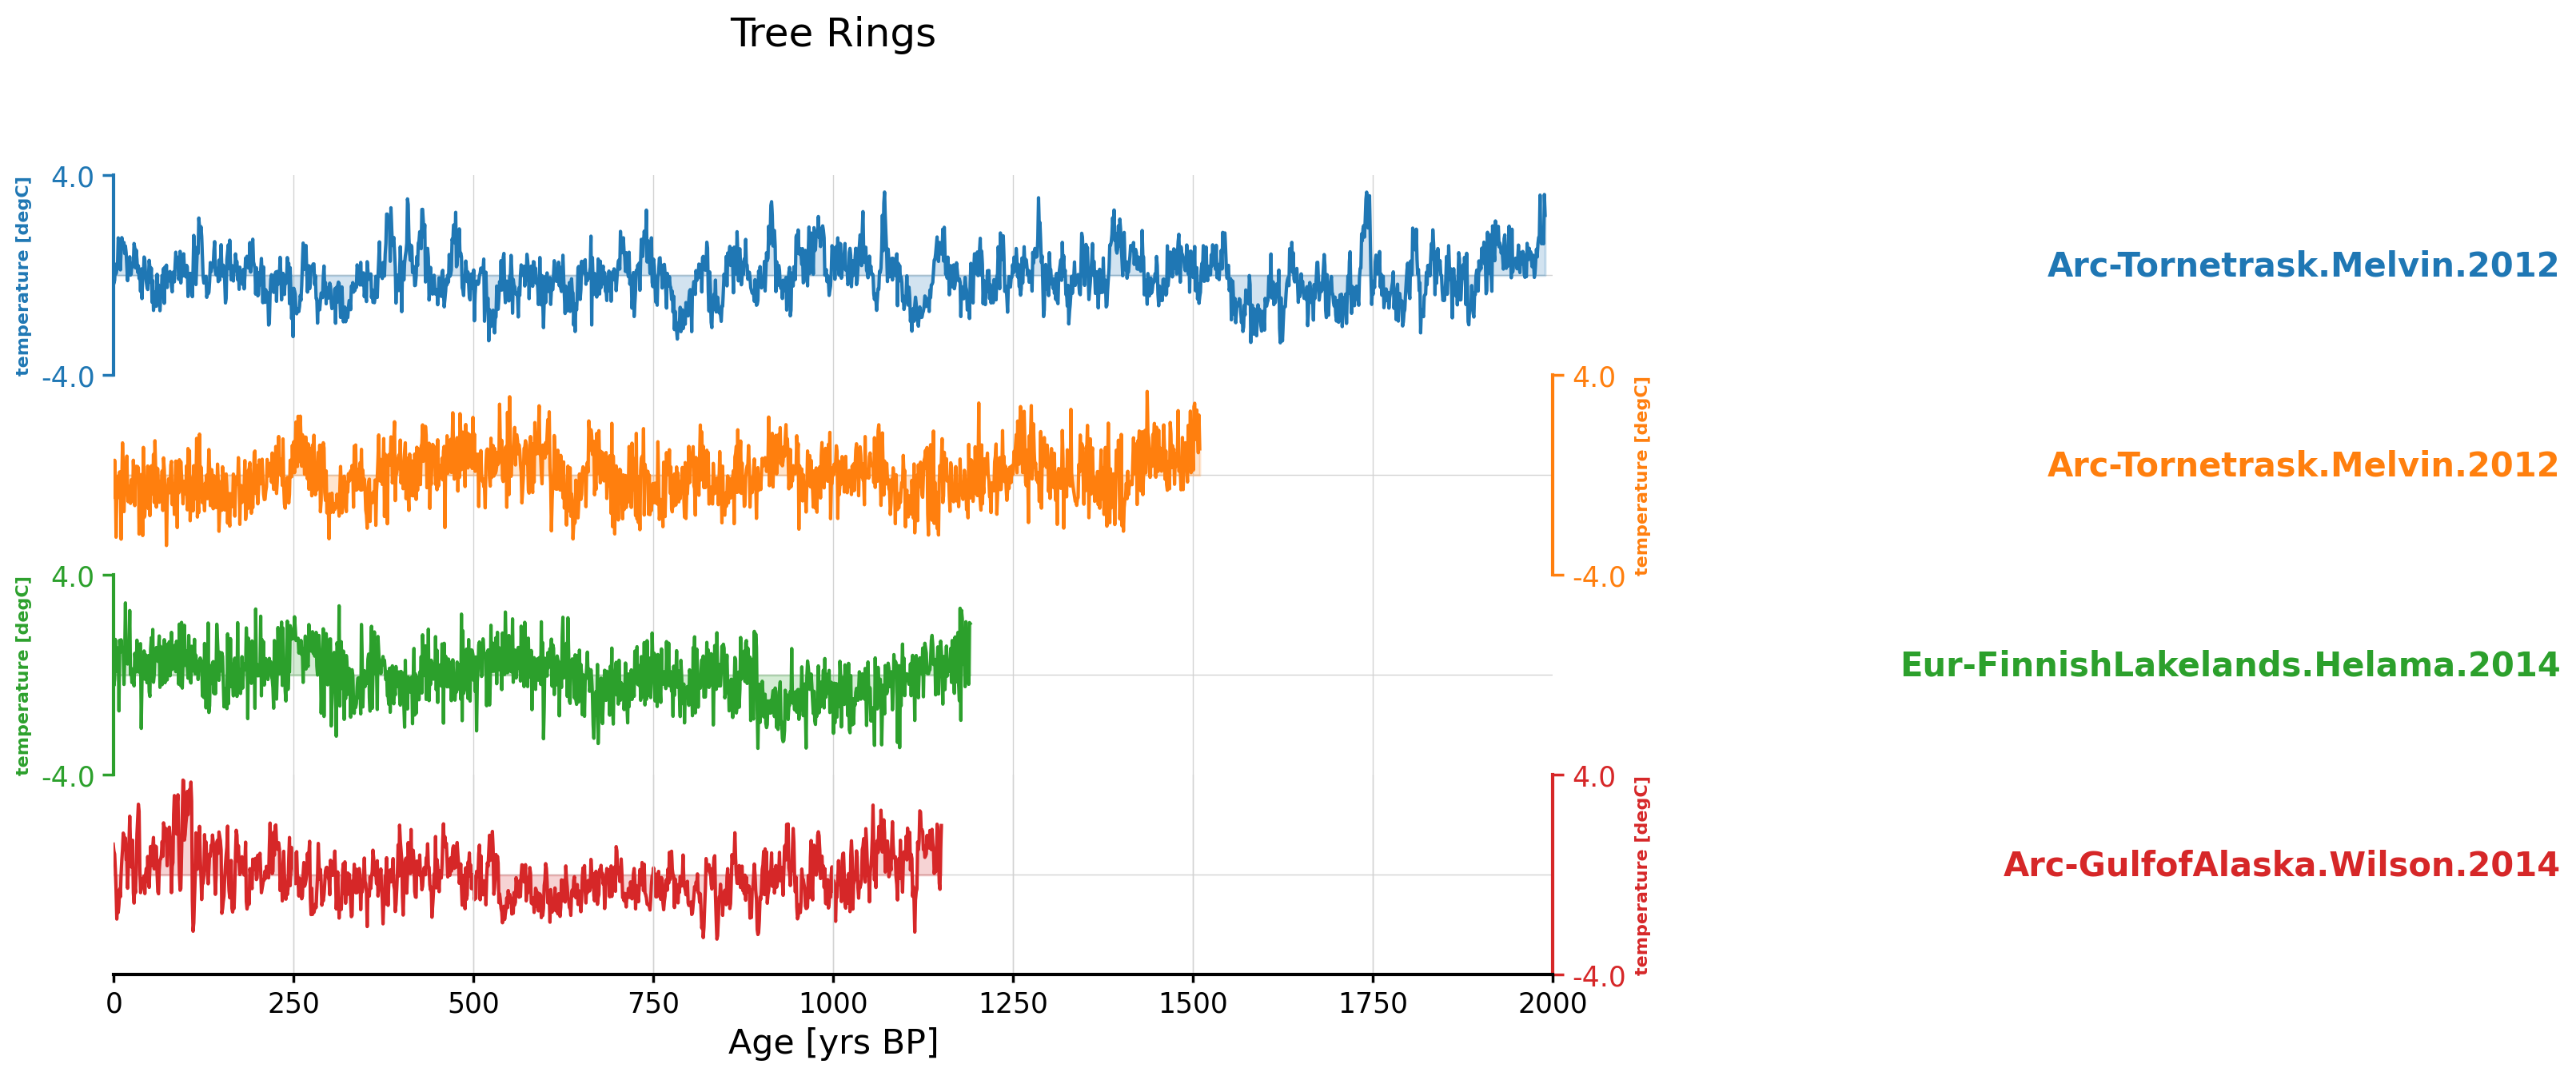

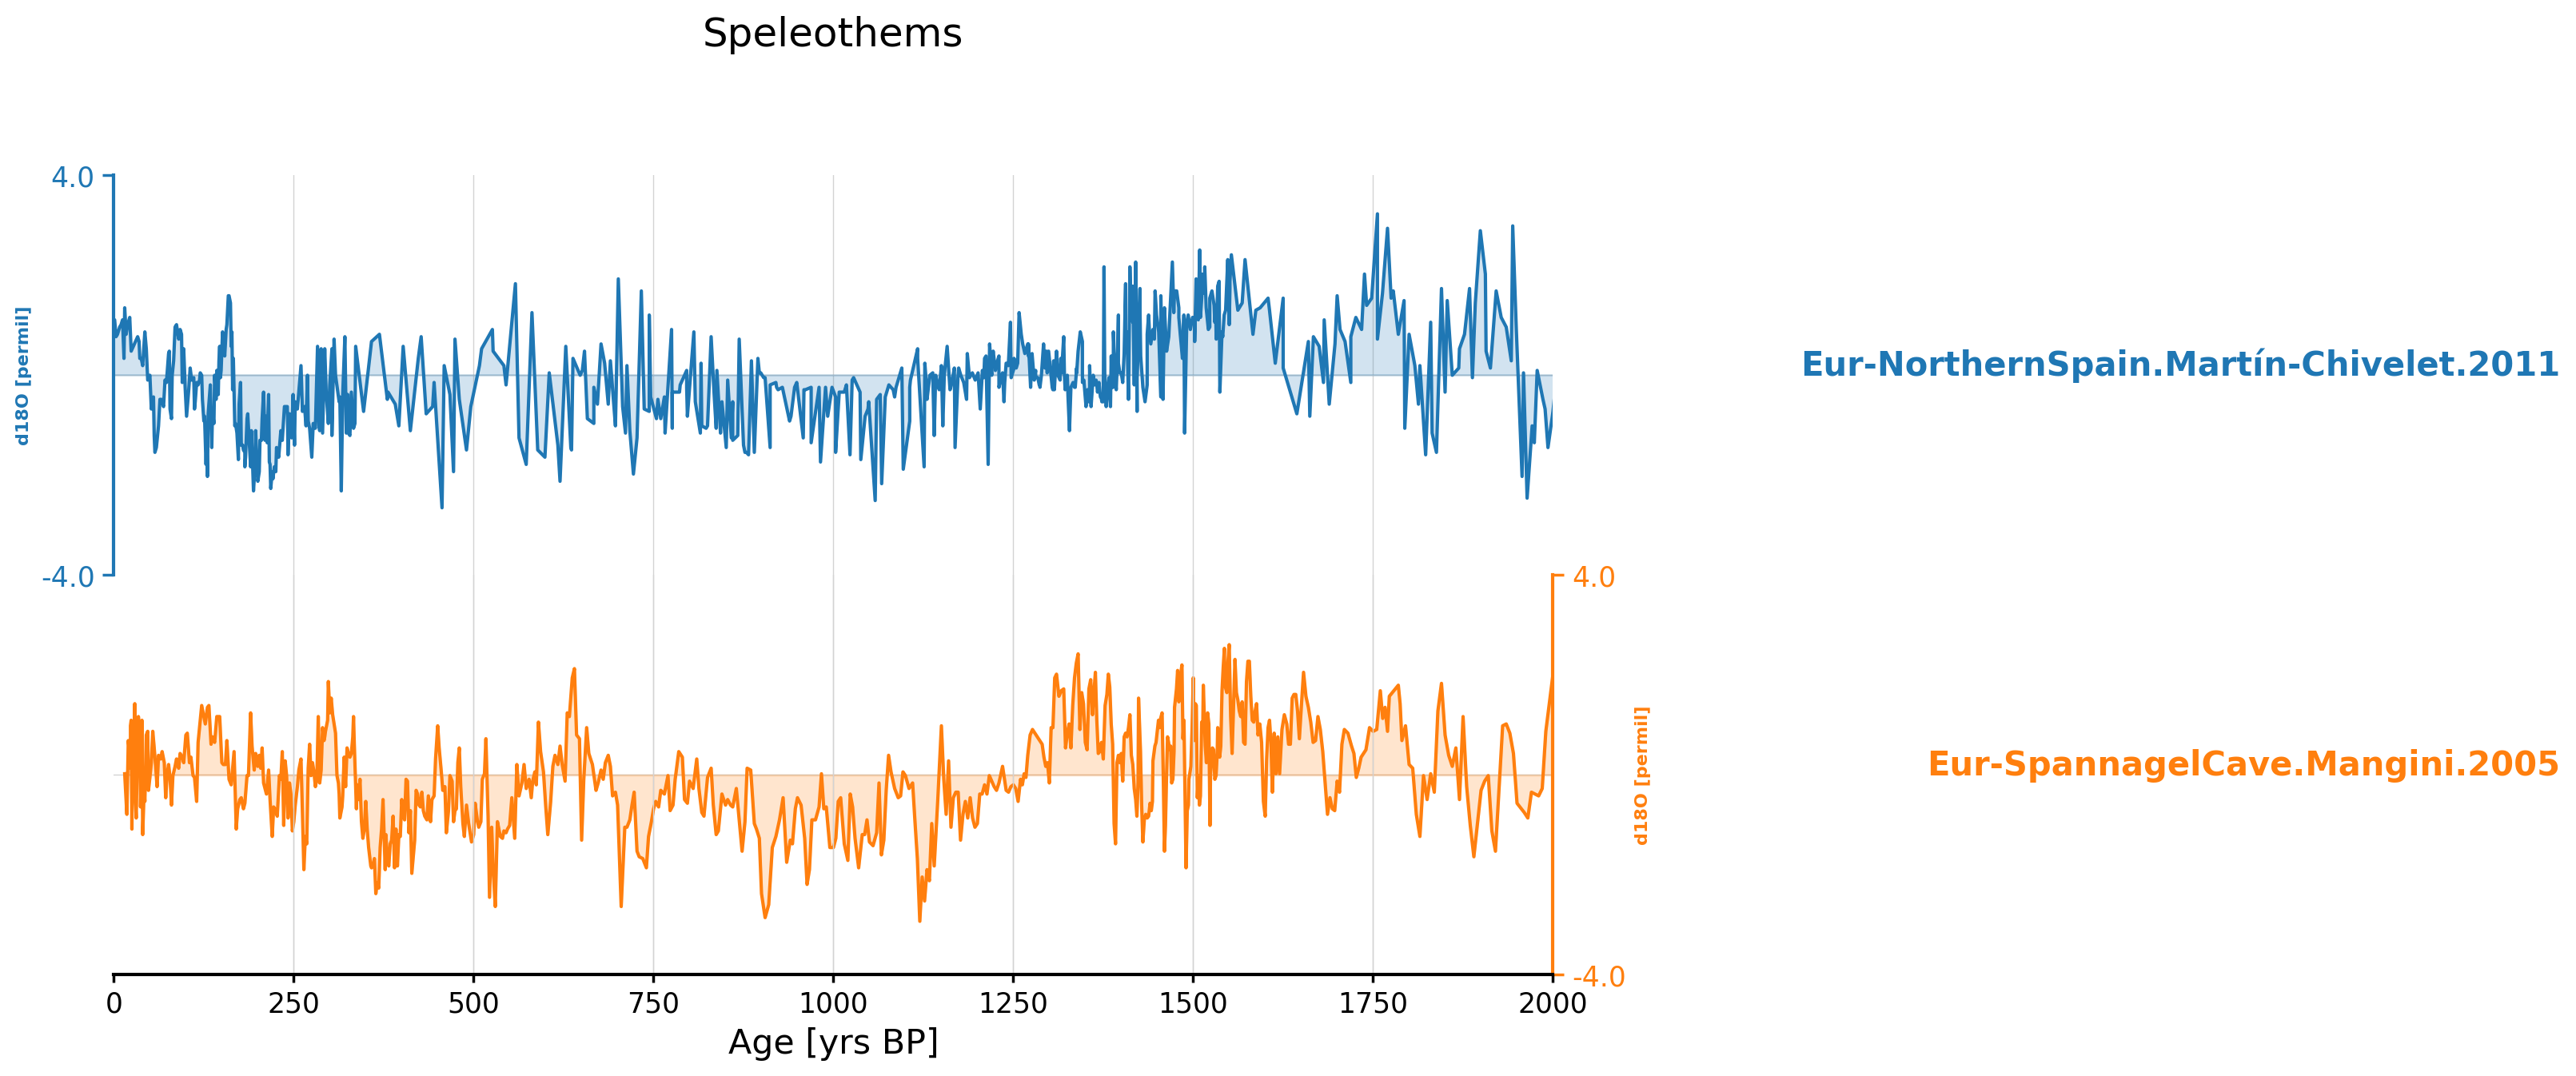

In [20]:
# note the x-axis is years before present,
# so reading from left to right corresponds to moving back in time

ax = lake_stnd.stackplot(
    label_x_loc=1.7,
    xlim=[0, 2000],
    v_shift_factor=1,
    figsize=[9, 5],
    time_unit="yrs BP",
)
ax[0].suptitle("Lake Cores", y=1.2)

ax = tree_stnd.stackplot(
    label_x_loc=1.7,
    xlim=[0, 2000],
    v_shift_factor=1,
    figsize=[9, 5],
    time_unit="yrs BP",
)
ax[0].suptitle("Tree Rings", y=1.2)

# recall d18O is a proxy for SST, and that more positive d18O means colder SST
ax = spel_stnd.stackplot(
    label_x_loc=1.7,
    xlim=[0, 2000],
    v_shift_factor=1,
    figsize=[9, 5],
    time_unit="yrs BP",
)
ax[0].suptitle("Speleothems", y=1.2)

## Questions 2


Using the plots we just made (and recalling that all of these records are from Europe), let's make some inferences about the temperature data over the past 2,000 years:

1.  Recall that &delta;<sup>18</sup>O is a proxy for SST, and that more positive &delta;<sup>18</sup>O means colder SST. Do the temperature records based on a single proxy type record similar patterns?
2.  Do the three proxy types collectively record similar patterns?
3.  What might be causing the more frequent variations in temperature?


[*Click for solution*](https://github.com/neuromatch/climate-course-content/tree/main/tutorials/W1D4_Paleoclimate/solutions/W1D4_Tutorial3_Solution_c2b80201.py)



In [ ]:
# @title Submit your feedback
content_review(f"{feedback_prefix}_Questions_2")

# Summary

In this tutorial, we explored how to use the Euro2k proxy network to investigate changes in temperature over the past 2,000 years from tree rings, speleothems, and lake sediments. To analyze these diverse datasets, we categorized them based on their archive type and constructed time series plots.


# Resources

Code for this tutorial is based on an existing notebook from LinkedEarth that provides instruction on [working with LiPD files](https://github.com/LinkedEarth/PyleoTutorials/blob/main/notebooks/L1_working_with_LiPD.ipynb).

Data from the following sources are used in this tutorial:

- Euro2k database: PAGES2k Consortium., Emile-Geay, J., McKay, N. et al. A global multiproxy database for temperature reconstructions of the Common Era. Sci Data 4, 170088 (2017). https://doi.org/10.1038/sdata.2017.88
